In [7]:
# =====================================================================

import itertools
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    roc_auc_score
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
from scipy.stats import chi2_contingency
from scipy import stats


# ─── HÀM 1: T-TEST (X LIÊN TỤC VS Y ĐỊNH TÍNH NHỊ PHÂN) ─────────────────────
def filter_by_ttest(df, cont_col, binary_target_col):
    """Kiểm định mối quan hệ giữa Biến độc lập (Liên tục) và Biến phụ thuộc (Định tính 2 nhóm).

    Sử dụng Welch's T-test (equal_var=False) để đảm bảo an toàn phân phối.
    """
    # Làm sạch dữ liệu khuyết thiếu (NaN)
    valid_data = df[[cont_col, binary_target_col]].dropna()

    # Lấy nhãn của 2 nhóm trong biến phụ thuộc
    groups = valid_data[binary_target_col].unique()

    # Tách biến liên tục thành 2 mảng độc lập dựa trên nhãn định tính
    group1 = valid_data[valid_data[binary_target_col] == groups[0]][
        cont_col
    ].values
    group2 = valid_data[valid_data[binary_target_col] == groups[1]][
        cont_col
    ].values

    # Chạy kiểm định Welch's t-test
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    conclusion = (
        "CÓ ý nghĩa thống kê (Bác bỏ H₀)"
        if p_value < 0.05
        else "KHÔNG có ý nghĩa (Chấp nhận H₀)"
    )

    print(
        f"--- KIỂM ĐỊNH T-TEST: Độc lập [{cont_col}] vs Phụ thuộc [{binary_target_col}] ---"
    )
    print(f"  Chỉ số t-statistic : {t_stat:.4f}")
    print(f"  p-value            : {p_value:.4f}  →  {conclusion}\n")

    return p_value


# ─── HÀM 2: CHECK CHI-SQUARE (ĐA CỘNG TUYẾN GIỮA CÁC X PHÂN LOẠI) ───────────
def check_chi_square(df, col1, col2):
    """Kiểm định tính độc lập giữa 2 biến phân loại độc lập với nhau.

    Mục tiêu: Phát hiện hiện tượng Đa cộng tuyến phân loại .
    """
    # Lập bảng tần suất chéo (Contingency Table) giữa 2 đặc trưng
    contingency_table = pd.crosstab(df[col1], df[col2])

    # Chạy kiểm định Chi-Square độc lập
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    conclusion = (
        "CÓ ĐA CỘNG TUYẾN (Bác bỏ H₀ - Hai biến phụ thuộc nhau)"
        if p_value < 0.05
        else "AN TOÀN (Chấp nhận H₀ - Hai biến độc lập nhau)"
    )

    print(f"--- KIỂM ĐỊNH ĐA CỘNG TUYẾN PHÂN LOẠI: [{col1}] & [{col2}] ---")
    print(f"  Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"  p-value            : {p_value:.4f}  →  {conclusion}\n")

    return p_value


# ─── HÀM 3: FILTER CHI-SQUARE + CRAMER'S V (X PHÂN LOẠI VS Y ĐỊNH TÍNH) ─────
def filter_by_chi_square(df, cat_col, target_col):
    """Kiểm định mối quan hệ giữa Biến độc lập (Phân loại) và Biến phụ thuộc (Định tính).

    Tính toán thêm hệ số Cramer's V để đo lường độ mạnh tương quan phân loại.
    """
    # Lập bảng tần suất chéo
    contingency_table = pd.crosstab(df[cat_col], df[target_col])

    # 1. Tính toán Chi-Square để lấy p-value
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    # 2. Tính toán Cramer's V (Kích thước hiệu ứng / Hệ số tương quan phân loại)
    n = contingency_table.sum().sum()  # Tổng số lượng mẫu dữ liệu sạch
    r, c = contingency_table.shape  # Số lượng hàng và số lượng cột của bảng chéo
    min_dim = min(r - 1, c - 1)  # Lấy giá trị nhỏ nhất giữa (Hàng-1) và (Cột-1)

    # Công thức toán gốc của Cramer's V
    cramer_v = (
        np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 and n > 0 else 0
    )

    conclusion = (
        "CÓ ý nghĩa thống kê (Bác bỏ H₀)"
        if p_value < 0.05
        else "KHÔNG có ý nghĩa (Chấp nhận H₀)"
    )

    # Gợi ý đánh giá sức mạnh mối quan hệ theo tiêu chuẩn Cramer's V
    if cramer_v < 0.1:
        strength = "Rất yếu (Nên loại bỏ)"
    elif cramer_v < 0.3:
        strength = "Trung bình"
    else:
        strength = "Mạnh (Ưu tiên giữ lại để train)"

    print(
        f"--- KIỂM ĐỊNH FEATURE: Đặc trưng [{cat_col}] tác động lên Target [{target_col}] ---"
    )
    print(f"  p-value (Chi-Square) : {p_value:.4f}  →  {conclusion}")
    print(f"  Hệ số Cramer's V     : {cramer_v:.4f}  →  Sức mạnh: {strength}\n")

    return p_value, cramer_v

def compute_vif(df, features):
    """Tính VIF chính xác cho từng biến liên tục ."""
    # 1. Trích xuất các biến liên tục và xóa dòng trống
    X = df[features].dropna()
    
    # 2. BẮT BUỘC: Thêm cột hằng số const = 1 để làm điểm tựa cho thuật toán
    X_with_const = sm.add_constant(X)
    
    # 3. Tính toán VIF cho từng đặc trưng (bỏ qua cột const ở chỉ số đầu tiên)
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features
    vif_data["VIF"] = [
        variance_inflation_factor(X_with_const.values, i + 1) # i + 1 để bỏ qua cột const nằm ở vị trí index 0
        for i in range(len(features))
    ]
    
    # 4. Sắp xếp kết quả giảm dần để dễ quan sát
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_data.round(4)


#  Sử dụng mô hình Logistic Regression phân tích xem khách hàng có rời bỏ hay không ?


In [8]:
df =pd.read_csv("Telco Customer Churn.csv")

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print("--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---")
nan_ratio = df.isnull().mean()
print(nan_ratio)
print("-" * 50)

--- Tỉ lệ dữ liệu khuyết thiếu (NaN) trên từng cột ---
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64
--------------------------------------------------


# Bỏ đi cột định danh 

In [10]:
# Loại bỏ các cột định danh không có ý nghĩa phân tích
df = df.drop(columns=['customerID'])
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Chỉnh lại kiểu dữ liệu 

In [11]:


# 1. Ép kiểu TotalCharges từ Chuỗi sang Số
# Tham số errors='coerce' cực kỳ quyền lực: Nó sẽ ép các khoảng trắng " " thành giá trị khuyết NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Kiểm tra lại thành quả
print("--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---")
print(df[[ 'TotalCharges']].dtypes)

--- KIỂM TRA LẠI KIỂU DỮ LIỆU ---
TotalCharges    float64
dtype: object


# Xem nhãn của từng cột 

In [12]:
# 1. Gom tất cả các cột phân loại (dạng chữ hoặc mã nhãn) vào một danh sách
categorical_cols_telco = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

# 2. Chạy vòng lặp để in tự động và trình bày đẹp mắt
print("="*50)
print("THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI")
print("="*50)

for col in categorical_cols_telco:
    print(f"\n Cột: [{col}]")
    print("-" * 30)
    print(df[col].value_counts())

THỐNG KÊ TẦN SUẤT CÁC BIẾN PHÂN LOẠI

 Cột: [gender]
------------------------------
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Cột: [SeniorCitizen]
------------------------------
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Cột: [Partner]
------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Cột: [Dependents]
------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 Cột: [PhoneService]
------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 Cột: [MultipleLines]
------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 Cột: [InternetService]
------------------------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 Cột: [OnlineSecurity]
------------------------------
OnlineSecurity
No      

# Phân tích biến liên tục 

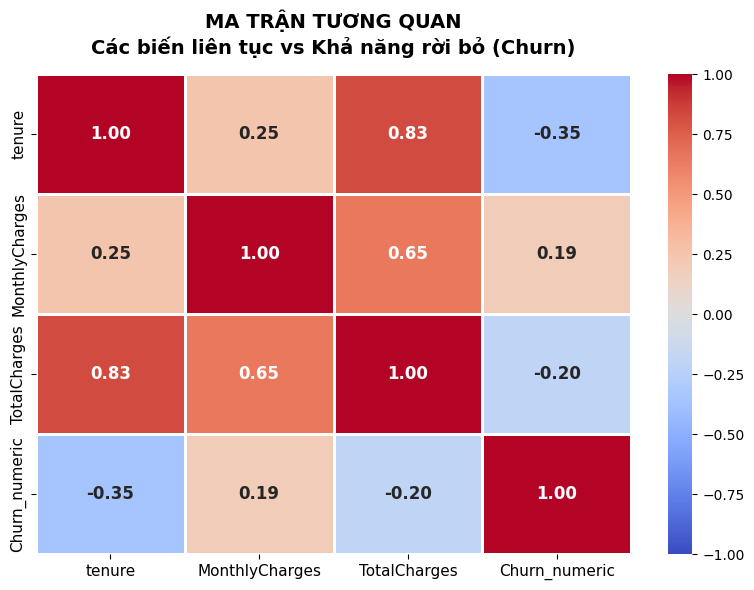

In [13]:


# ==========================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU
# ==========================================
# Ép Churn thành 1 (Rời bỏ) và 0 (Ở lại)
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Danh sách các biến liên tục + biến mục tiêu
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']

# Trích xuất dataframe chỉ chứa các cột số này
df_corr = df[continuous_cols]

# Tính toán ma trận tương quan (Pearson)
corr_matrix = df_corr.corr()

# ==========================================
# BƯỚC 2: VẼ BIỂU ĐỒ HEATMAP
# ==========================================
plt.figure(figsize=(8, 6))

# Cấu hình màu sắc (coolwarm: Xanh = Tương quan âm, Đỏ = Tương quan dương)
sns.heatmap(corr_matrix, 
            annot=True,              # Hiện con số trên từng ô
            fmt=".2f",               # Lấy 2 chữ số thập phân
            cmap="coolwarm",         # Bảng màu
            vmin=-1, vmax=1,         # Giới hạn thang đo từ -1 đến 1
            linewidths=1,            # Đường viền giữa các ô
            annot_kws={"size": 12, "weight": "bold"}) # Định dạng chữ số

plt.title('MA TRẬN TƯƠNG QUAN\nCác biến liên tục vs Khả năng rời bỏ (Churn)', 
          fontsize=14, fontweight='bold', pad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Xóa cột phụ sau khi vẽ xong để tránh rác dữ liệu
df = df.drop(columns=['Churn_numeric'])

# Trực quan bằng box plot 

C:\Users\Admin\AppData\Local\Temp\ipykernel_2296\1841380280.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_2296\1841380280.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_2296\1841380280.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


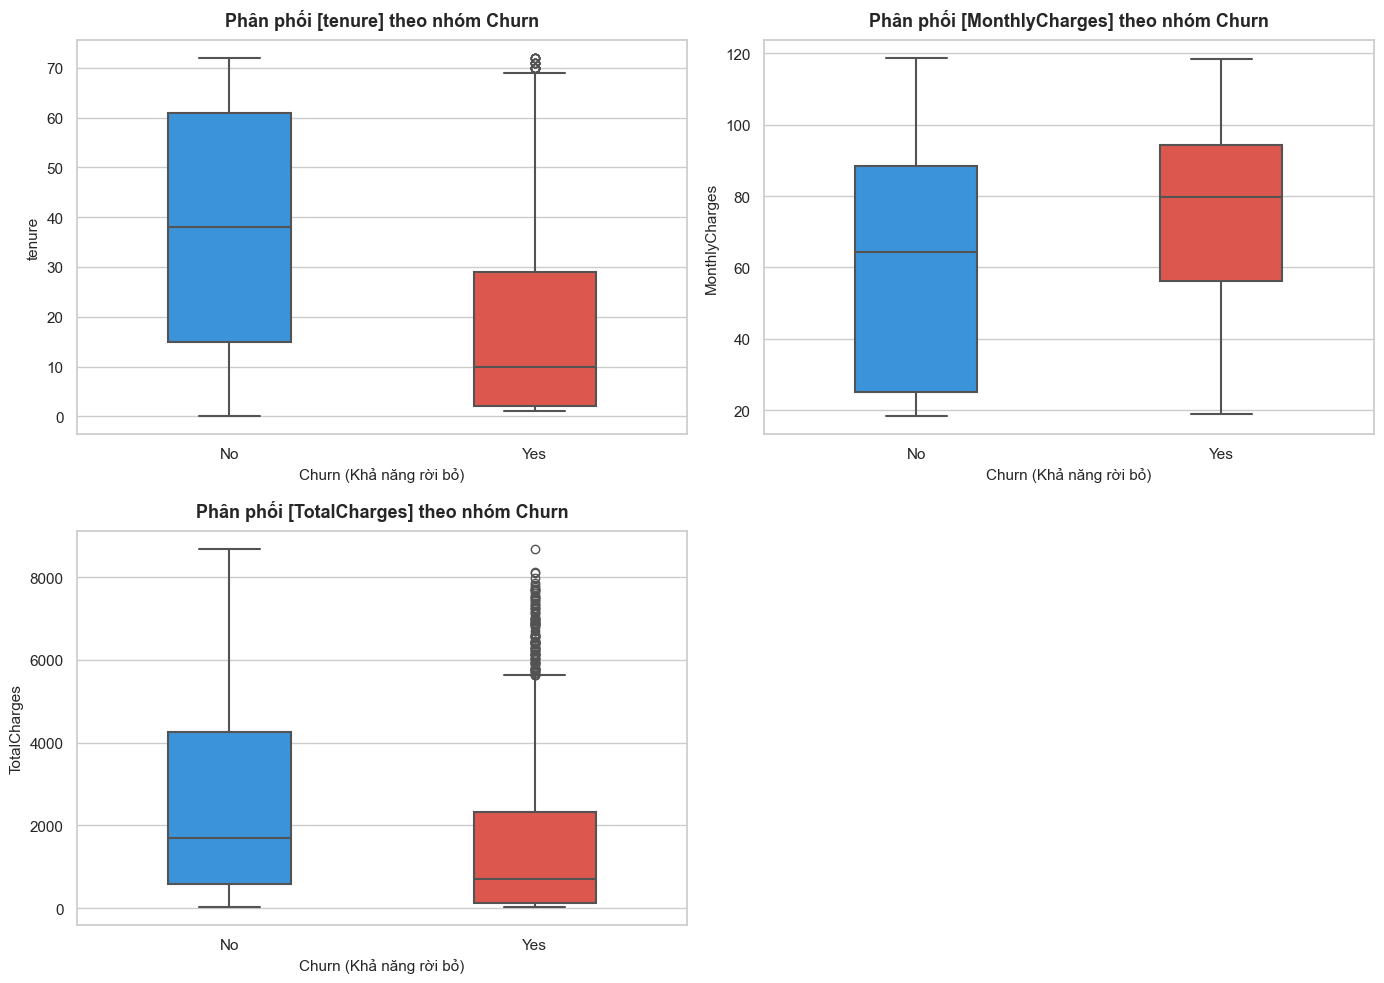

In [14]:


# ==========================================
# 1. KHAI BÁO BIẾN DỮ LIỆU TELCO
# ==========================================
continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
target = 'Churn'

# ==========================================
# 2. THIẾT LẬP KHUNG ĐỒ THỊ (LƯỚI 2x2)
# ==========================================
sns.set_theme(style="whitegrid")
# Vì chỉ có 3 biến, lưới 2x2 (4 ô) là đủ không gian hiển thị rộng rãi
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# ==========================================
# 3. VÒNG LẶP VẼ BOXPLOT TỰ ĐỘNG
# ==========================================
for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df,
        x=target,
        y=feature,
        ax=axes[i],
        # Mẹo chuyên nghiệp: Dùng dictionary để ép cố định màu cho Yes/No
        palette={'No': '#2196F3', 'Yes': '#F44336'}, 
        width=0.4,
        linewidth=1.5
    )
    
    # Trang trí chi tiết cho từng ô
    axes[i].set_title(f'Phân phối [{feature}] theo nhóm {target}', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('Churn (Khả năng rời bỏ)', fontsize=11)
    axes[i].set_ylabel(feature, fontsize=11)

# ==========================================
# 4. DỌN DẸP THẨM MỸ (Xóa ô thừa)
# ==========================================
# Vòng lặp này sẽ tự động phát hiện ô thứ 4 (axes[3]) bị trống và xóa nó đi
for j in range(len(continuous_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Tính chỉ số VIF 

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm
vif_df = compute_vif(df, continuous_features)
print(vif_df.to_string(index=False))
print()

       Feature    VIF
  TotalCharges 9.5267
        tenure 5.8446
MonthlyCharges 3.2253



# Kiểm định t-test cho các biến liên tục 

In [ ]:
for col in continuous_features:
    filter_by_ttest(df, cont_col=col, binary_target_col='Churn')

--- KIỂM ĐỊNH T-TEST: Độc lập [tenure] vs Phụ thuộc [Churn] ---
  Chỉ số t-statistic : 34.8238
  p-value            : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [MonthlyCharges] vs Phụ thuộc [Churn] ---
  Chỉ số t-statistic : -18.4075
  p-value            : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)

--- KIỂM ĐỊNH T-TEST: Độc lập [TotalCharges] vs Phụ thuộc [Churn] ---
  Chỉ số t-statistic : 18.8008
  p-value            : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)



# Mặc dù sau khi kiểm định t-test TotalCharges có ý nghĩa thống kê nhưng chỉ số VIF quá cao sẽ dễ gây ra hiện tượng đa cộng tuyến nên quyết định loại bỏ biến liên tục TotalCharges 

# xóa đi totalcharges 

In [16]:
df.drop(columns=['TotalCharges'], inplace=True)

print(" Đã xóa xong TotalCharges!")
print("Kích thước bộ dữ liệu hiện tại:", df.shape)

 Đã xóa xong TotalCharges!
Kích thước bộ dữ liệu hiện tại: (7043, 19)


# Phân tích các biến phân loại 

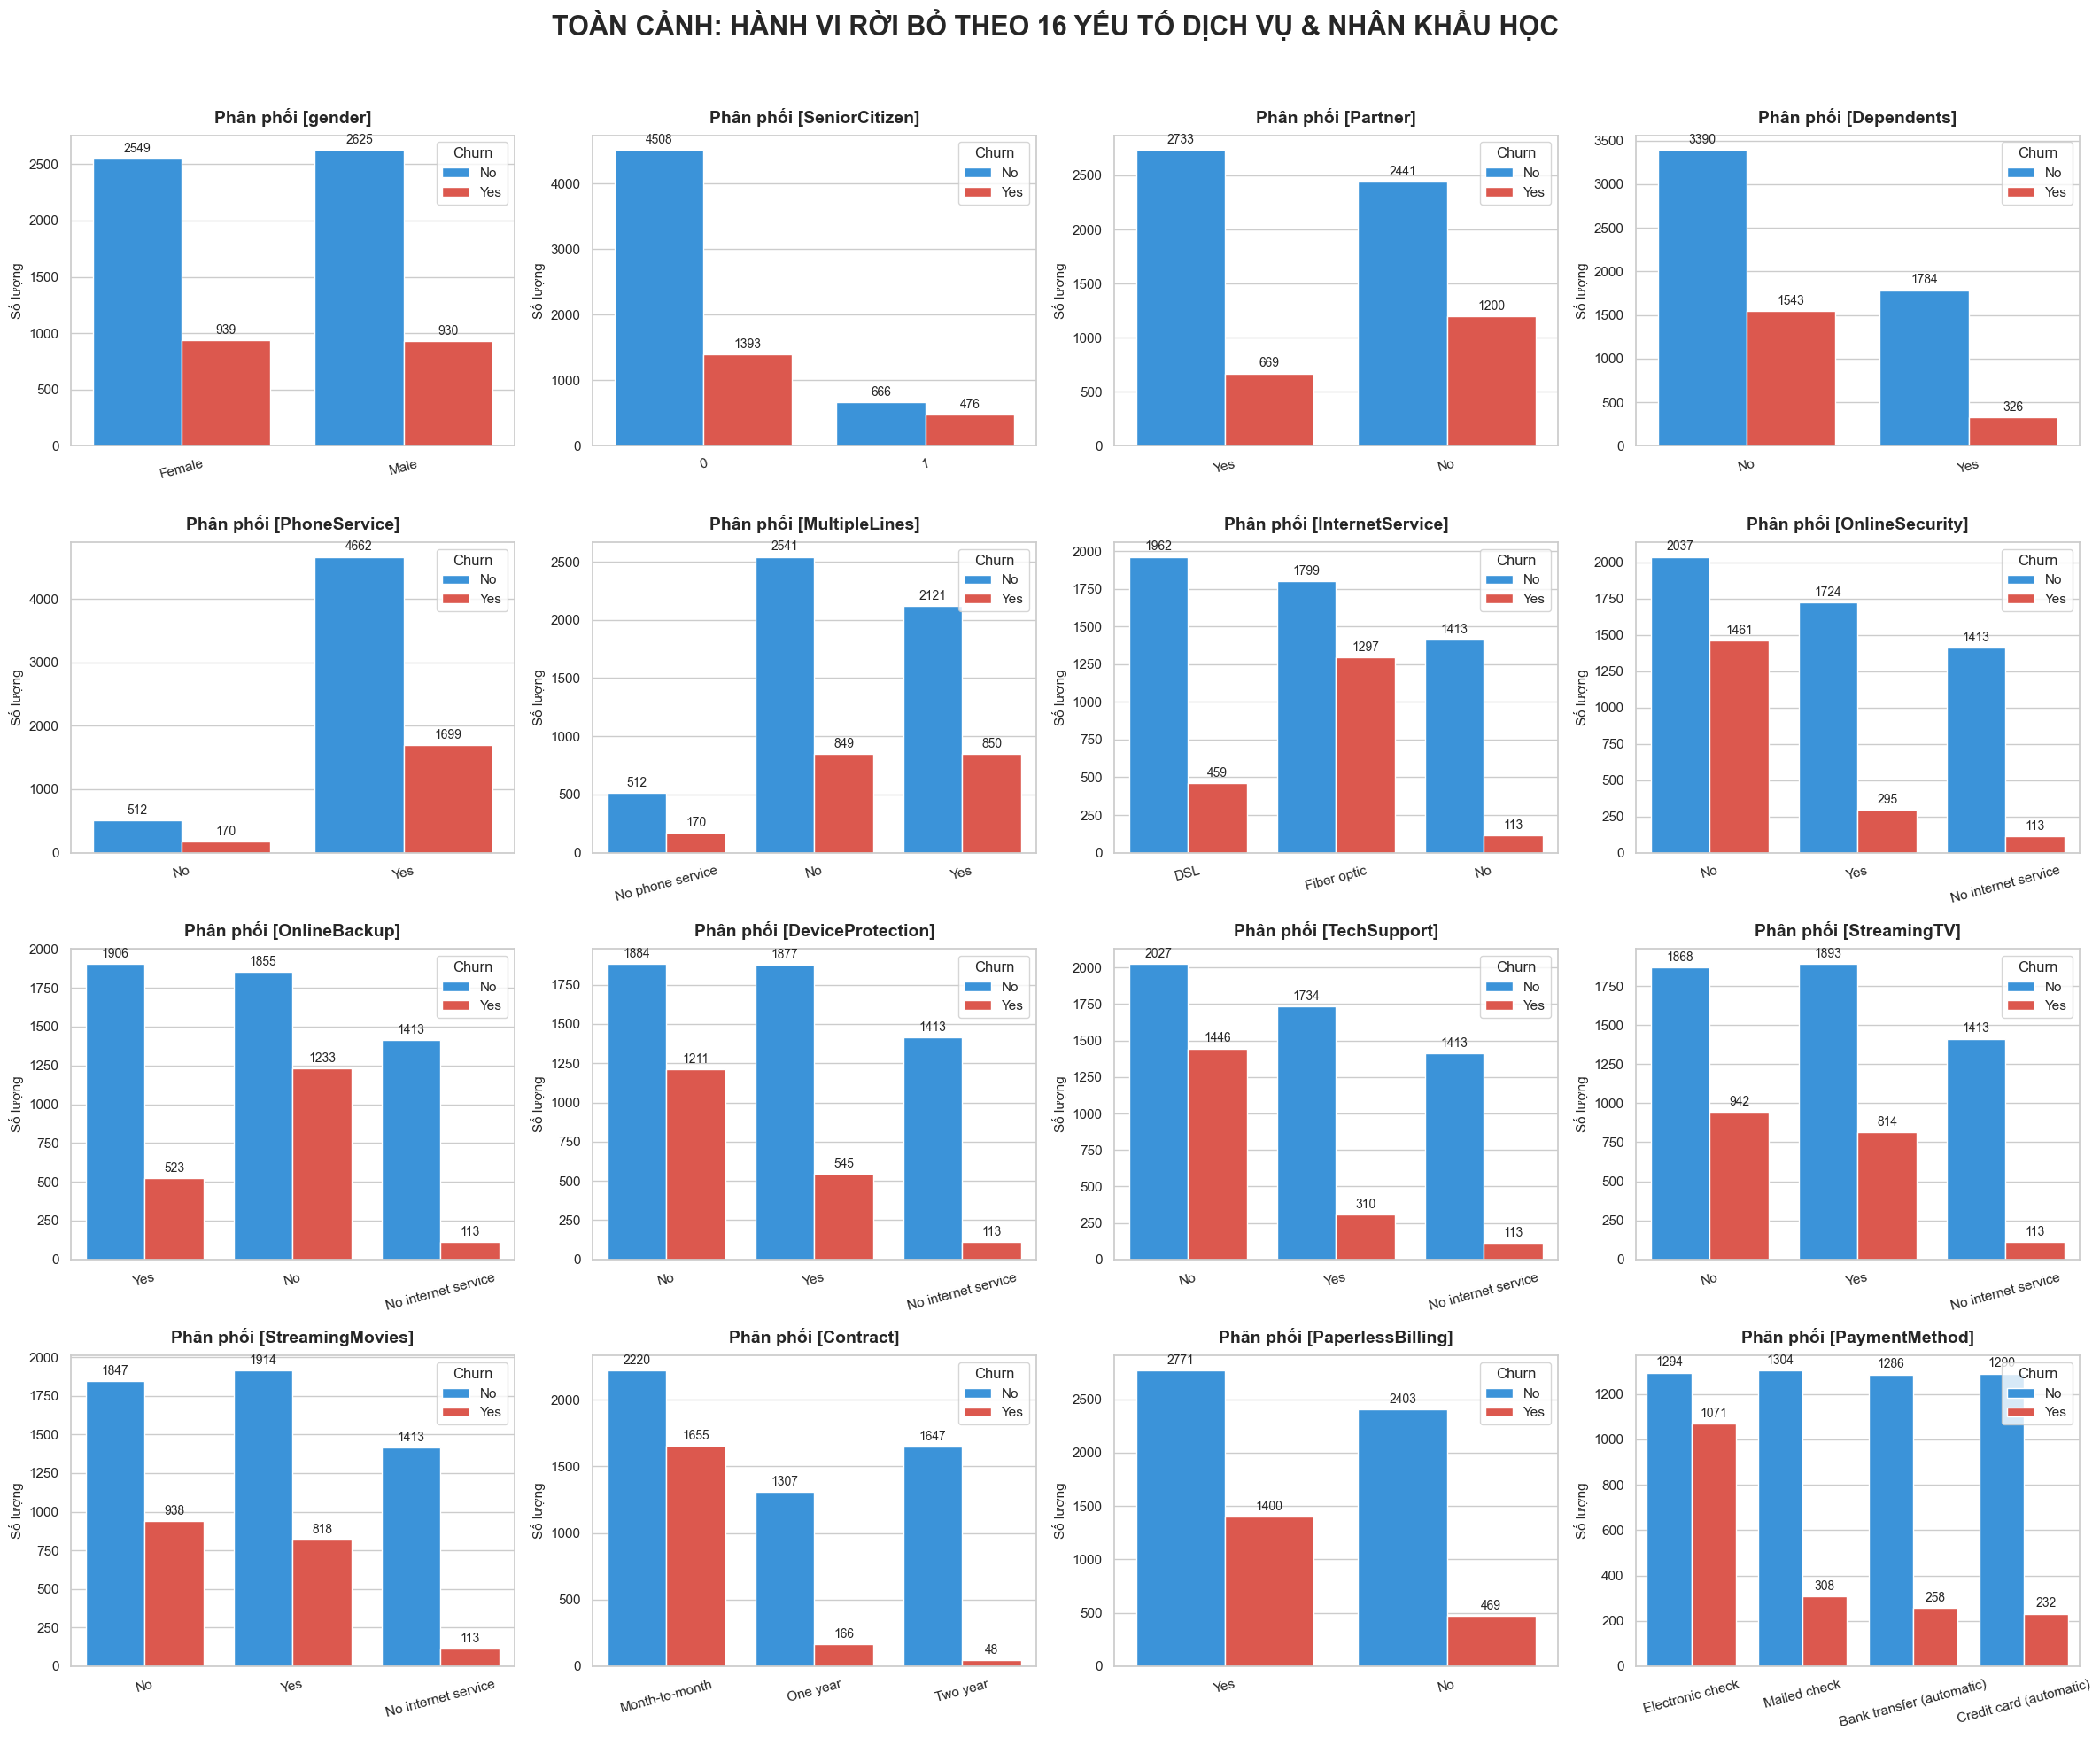

In [17]:


# ==========================================
# 1. KHAI BÁO BIẾN DỮ LIỆU TELCO
# ==========================================
# Tổng hợp 16 biến phân loại quan trọng nhất
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]
target = 'Churn'

# ==========================================
# 2. THIẾT LẬP KHUNG ĐỒ THỊ KHỔNG LỒ (4x4)
# ==========================================
sns.set_theme(style="whitegrid")

# Tạo lưới 4 hàng x 4 cột (chứa trọn vẹn 16 biến). Tăng kích thước figsize lớn lên.
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(24, 20))
axes = axes.flatten()

# ==========================================
# 3. VÒNG LẶP VẼ COUNTPLOT TỰ ĐỘNG
# ==========================================
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=target,
        ax=axes[i],
        # Dùng lại mảng màu chiến thuật: Xanh (Ở lại) - Đỏ (Rời bỏ)
        palette={'No': '#2196F3', 'Yes': '#F44336'} 
    )

    # Trang trí tiêu đề từng ô
    axes[i].set_title(f'Phân phối [{col}]', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('')  # Ẩn tên trục X vì tiêu đề đã thể hiện rõ
    axes[i].set_ylabel('Số lượng', fontsize=11)

    # Xoay nghiêng chữ ở trục X đi 15 độ để các chữ dài không bị đè lên nhau
    axes[i].tick_params(axis='x', rotation=15)

    # Cấu hình Legend (Ghi chú) cho từng ô
    axes[i].legend(title='Churn', labels=['No', 'Yes'], loc='upper right')

    # In con số trực tiếp lên đỉnh mỗi cột
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=10, padding=3)

# ==========================================
# 4. HOÀN THIỆN VÀ HIỂN THỊ
# ==========================================
# Xóa các ô thừa (phòng trường hợp danh sách ít hơn 16 biến)
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

# Tiêu đề tổng quát cho toàn bộ bức tranh
plt.suptitle('TOÀN CẢNH: HÀNH VI RỜI BỎ THEO 16 YẾU TỐ DỊCH VỤ & NHÂN KHẨU HỌC', 
             fontsize=22, fontweight='bold', y=0.98)

# Căn chỉnh để tiêu đề tổng không bị đè lên các đồ thị con
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [18]:
target = "Churn"

print("=" * 70)
print("SÀNG LỌC ĐẶC TRƯNG MẠNH (X PHÂN LOẠI VS TARGET NHỊ PHÂN Y)")
print("=" * 70)

for col in cat_cols:
    filter_by_chi_square(df, cat_col=col, target_col=target)

SÀNG LỌC ĐẶC TRƯNG MẠNH (X PHÂN LOẠI VS TARGET NHỊ PHÂN Y)
--- KIỂM ĐỊNH FEATURE: Đặc trưng [gender] tác động lên Target [Churn] ---
  p-value (Chi-Square) : 0.4866  →  KHÔNG có ý nghĩa (Chấp nhận H₀)
  Hệ số Cramer's V     : 0.0083  →  Sức mạnh: Rất yếu (Nên loại bỏ)

--- KIỂM ĐỊNH FEATURE: Đặc trưng [SeniorCitizen] tác động lên Target [Churn] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1505  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [Partner] tác động lên Target [Churn] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1501  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [Dependents] tác động lên Target [Churn] ---
  p-value (Chi-Square) : 0.0000  →  CÓ ý nghĩa thống kê (Bác bỏ H₀)
  Hệ số Cramer's V     : 0.1639  →  Sức mạnh: Trung bình

--- KIỂM ĐỊNH FEATURE: Đặc trưng [PhoneService] tác động lên Target [Churn] ---
  p-value (Chi-Square) : 0.3388  →  KH

# Kiểm tra đa cộng tuyến 

In [ ]:


# ====================================================================
# 1. HÀM TÍNH TOÁN CRAMER'S V (Tái sử dụng hàm chuẩn)
# ====================================================================
def calculate_cramers_v(df, col1, col2):
    crosstab = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    min_dim = min(crosstab.shape) - 1
    cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    return p, cramer_v

# ====================================================================
# 2. KHAI BÁO 3 BIẾN ĐÃ BỊ LOẠI BỎ
# ====================================================================
dropped_cols = ['gender', 'PhoneService', 'MultipleLines']

print("=" * 70)
print("KIỂM TRA SỰ TRÙNG LẶP (CRAMER'S V) CỦA CÁC BIẾN BỊ LOẠI BỎ")
print("=" * 70)

results = []

# Quét các cặp trong 3 biến này
for col1, col2 in itertools.combinations(dropped_cols, 2):
    p_val, cramer_v = calculate_cramers_v(df, col1, col2)
    results.append({
        'Biến 1': col1,
        'Biến 2': col2,
        "Cramer's V (Độ trùng lặp)": cramer_v
    })

# Hiển thị kết quả
df_dropped_results = pd.DataFrame(results).sort_values(by="Cramer's V (Độ trùng lặp)", ascending=False).reset_index(drop=True)
print(df_dropped_results.to_string(index=False))

KIỂM TRA SỰ TRÙNG LẶP (CRAMER'S V) CỦA CÁC BIẾN BỊ LOẠI BỎ
      Biến 1        Biến 2  Cramer's V (Độ trùng lặp)
PhoneService MultipleLines                   1.000000
      gender MultipleLines                   0.009452
      gender  PhoneService                   0.006008


# Nhận xét: 
Thực tế dữ liệu: Nếu một người không đăng ký dịch vụ điện thoại (PhoneService = "No"), thì chắc chắn cột đa đường dây của họ cũng sẽ là không có (MultipleLines = "No phone service"). Thuật toán không cần đọc cột thứ hai cũng có thể tự suy ra được kết quả từ cột thứ nhất. Giữ cả hai cột này trong mô hình Học máy sẽ gây ra lỗi đa cộng tuyến hoàn hảo, làm nhiễu loạn trọng số của thuật toán.

# Quyết định loại bỏ cột 3 cột gender, multiplelines, phoneservice 


In [26]:


# =====================================================================
# BƯỚC 1: LÀM SẠCH DỮ LIỆU (df_clean)
# =====================================================================
df_clean = df.copy()


# Gộp nhãn 'No internet service' thành 'No' cho 6 dịch vụ mạng
internet_services_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in internet_services_cols:
    if col in df_clean.columns:  # Kiểm tra an toàn trước khi gộp
        df_clean[col] = df_clean[col].replace('No internet service', 'No')



# Kỹ thuật biến giả 

In [28]:


print("=" * 70)
print("ÁP DỤNG KỸ THUẬT BIẾN GIẢ (DUMMY VARIABLES) VÀ XÓA BẪY NAN")
print("=" * 70)

# =====================================================================
# 1. ÁP DỤNG KỸ THUẬT BIẾN GIẢ BẰNG PANDAS
# =====================================================================
# Giả sử df_clean là bộ dữ liệu đã được dọn dẹp các nhãn dư thừa
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Churn') # Tách riêng biến mục tiêu

# ĐÂY CHÍNH LÀ KỸ THUẬT BIẾN GIẢ: dùng get_dummies với drop_first=True (Quy tắc k-1)
df_dummy = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True, dtype=int)

# Mã hóa biến mục tiêu Churn thành 1/0
df_dummy['Churn'] = df_dummy['Churn'].map({'Yes': 1, 'No': 0})



ÁP DỤNG KỸ THUẬT BIẾN GIẢ (DUMMY VARIABLES) VÀ XÓA BẪY NAN


C:\Users\Admin\AppData\Local\Temp\ipykernel_2296\799470875.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


# Huấn luyện mô hình Logistic Regression 

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("QUY TRÌNH HỒI QUY LOGISTIC (SCIKIT-LEARN) ĐÃ TỐI ƯU BIẾN GIẢ")
print("=" * 70)

# =====================================================================
# BƯỚC 1: CHỌN BIẾN, LÀM SẠCH VÀ GỘP NHÃN
# =====================================================================
# LƯU Ý: Đã loại bỏ cả TotalCharges VÀ MonthlyCharges để né bẫy đa cộng tuyến
selected_columns = [
    'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
    'PaperlessBilling', 'PaymentMethod', 'Churn'
]

df_model = df[selected_columns].copy()

# Gộp nhãn "No internet service" thành "No" cho 6 dịch vụ mạng
internet_services_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_services_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].replace('No internet service', 'No')

# Chuyển đổi thủ công biến mục tiêu 'Churn' từ chữ sang số
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# =====================================================================
# BƯỚC 2: MÃ HÓA ONE-HOT VỚI QUY TẮC K-1
# =====================================================================
# Tự động lấy danh sách các biến chữ còn lại để mã hóa
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()

df_encoded = pd.get_dummies(df_model, 
                            columns=categorical_cols, 
                            drop_first=True, 
                            dtype=int)

print(f"Kích thước X chuẩn bị đưa vào mô hình: {df_encoded.shape[1] - 1} biến đầu vào")

# =====================================================================
# BƯỚC 3: TÁCH BIẾN ĐẦU VÀO (X) VÀ MỤC TIÊU (y)
# =====================================================================
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# =====================================================================
# BƯỚC 4: CẤU HÌNH BỘ XÁC THỰC CHÉO (STRATIFIED K-FOLD) VÀ MÔ HÌNH
# =====================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
log_reg = LogisticRegression(max_iter=1000, random_state=42)

fold_accuracies = []
fold_roc_aucs = []

print("\n" + "=" * 60)
print("BẮT ĐẦU HUẤN LUYỆN LOGISTIC REGRESSION (5-FOLD CV)")
print("=" * 60)

# =====================================================================
# BƯỚC 5: TIẾN HÀNH VÒNG LẶP HUẤN LUYỆN
# =====================================================================
for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    # Chia dữ liệu
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Chuẩn hóa (Fit trên Train, Transform trên Train & Test)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Huấn luyện
    log_reg.fit(X_train_scaled, y_train)
    
    # Dự đoán
    y_pred = log_reg.predict(X_test_scaled)
    y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
    
    # Đánh giá
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    fold_accuracies.append(acc)
    fold_roc_aucs.append(roc_auc)
    
    print(f"Fold {fold}: Accuracy = {acc:.4f} | ROC AUC = {roc_auc:.4f}")

# =====================================================================
# BƯỚC 6: TỔNG KẾT VÀ BÁO CÁO TOÀN DIỆN
# =====================================================================
print("-" * 60)
print(f" TRUNG BÌNH CHUNG SAU 5 FOLDS:")
print(f"   Độ chính xác (Accuracy) : {np.mean(fold_accuracies):.4f}")
print(f"   Chỉ số ROC AUC          : {np.mean(fold_roc_aucs):.4f}")
print("-" * 60)

print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT (Từ Fold cuối cùng):")
print(classification_report(y_test, y_pred, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

QUY TRÌNH HỒI QUY LOGISTIC (SCIKIT-LEARN) ĐÃ TỐI ƯU BIẾN GIẢ
Kích thước X chuẩn bị đưa vào mô hình: 18 biến đầu vào

BẮT ĐẦU HUẤN LUYỆN LOGISTIC REGRESSION (5-FOLD CV)
Fold 1: Accuracy = 0.8141 | ROC AUC = 0.8528
Fold 2: Accuracy = 0.8013 | ROC AUC = 0.8416
Fold 3: Accuracy = 0.8190 | ROC AUC = 0.8595
Fold 4: Accuracy = 0.7876 | ROC AUC = 0.8241
Fold 5: Accuracy = 0.7969 | ROC AUC = 0.8337
------------------------------------------------------------
 TRUNG BÌNH CHUNG SAU 5 FOLDS:
   Độ chính xác (Accuracy) : 0.8038
   Chỉ số ROC AUC          : 0.8423
------------------------------------------------------------

BÁO CÁO PHÂN LOẠI CHI TIẾT (Từ Fold cuối cùng):
              precision    recall  f1-score   support

   Ở lại (0)       0.84      0.90      0.87      1034
  Rời bỏ (1)       0.64      0.52      0.58       374

    accuracy                           0.80      1408
   macro avg       0.74      0.71      0.72      1408
weighted avg       0.79      0.80      0.79      1408



C:\Users\Admin\AppData\Local\Temp\ipykernel_2296\1336867344.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()


In [30]:

print("\n" + "=" * 80)
print("ĐANG TÍNH TOÁN BẢNG THỐNG KÊ CHI TIẾT (STATSMODELS)...")
print("=" * 80)

# 1. Chuẩn hóa TOÀN BỘ tập X (Để xem xét mức độ ảnh hưởng chung của toàn bộ tập khách hàng)
# Lưu ý: StandardScaler trả về ma trận numpy bị mất tên cột
scaler_sm = StandardScaler()
X_scaled_array = scaler_sm.fit_transform(X)

# 2. Khôi phục lại tên cột (BẮT BUỘC để bảng summary hiện tên biến dễ đọc)
X_scaled_df = pd.DataFrame(X_scaled_array, columns=X.columns, index=X.index)

# 3. Thêm hệ số chặn (Intercept / Bias) - Không giống sklearn tự thêm, statsmodels bắt buộc phải khai báo thủ công
X_const = sm.add_constant(X_scaled_df)

# 4. Khởi tạo và huấn luyện mô hình
# Dùng maxiter=1000 và method='bfgs' (hoặc 'newton') để đảm bảo thuật toán dò được đến đáy thung lũng
logit_model = sm.Logit(y, X_const)
logit_result = logit_model.fit(method='bfgs', maxiter=1000, disp=False)

# 5. In bảng báo cáo thống kê
print("\n" + "=" * 80)
print("TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY LOGISTIC (STATSMODELS)")
print("=" * 80)
print(logit_result.summary())


ĐANG TÍNH TOÁN BẢNG THỐNG KÊ CHI TIẾT (STATSMODELS)...

TÓM TẮT KẾT QUẢ MÔ HÌNH HỒI QUY LOGISTIC (STATSMODELS)
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7024
Method:                           MLE   Df Model:                           18
Date:                T4, 24 Thg6 2026   Pseudo R-squ.:                  0.2790
Time:                        23:24:29   Log-Likelihood:                -2938.3
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -1.

ĐANG HUẤN LUYỆN MÔ HÌNH CUỐI CÙNG TRÊN TOÀN BỘ DỮ LIỆU TELCO...


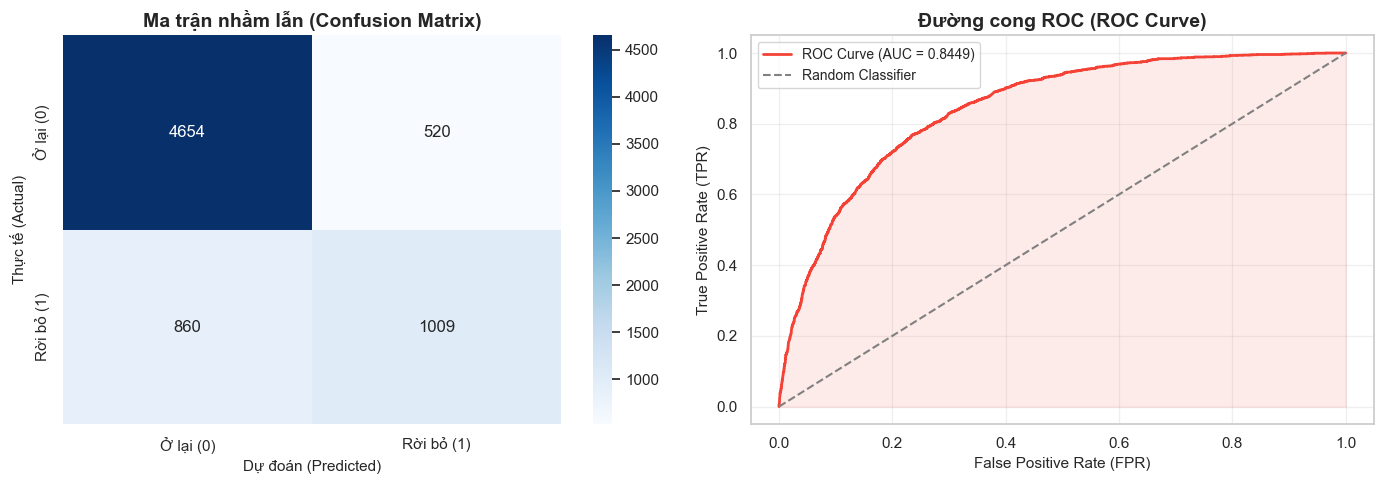


BÁO CÁO PHÂN LOẠI CHI TIẾT (TELCO CHURN)
              precision    recall  f1-score   support

   Ở lại (0)       0.84      0.90      0.87      5174
  Rời bỏ (1)       0.66      0.54      0.59      1869

    accuracy                           0.80      7043
   macro avg       0.75      0.72      0.73      7043
weighted avg       0.80      0.80      0.80      7043



In [31]:

print("=" * 80)
print("ĐANG HUẤN LUYỆN MÔ HÌNH CUỐI CÙNG TRÊN TOÀN BỘ DỮ LIỆU TELCO...")
print("=" * 80)

# =====================================================================
# BƯỚC 1: CHUẨN HÓA VÀ HUẤN LUYỆN MÔ HÌNH CHỐT (FINAL MODEL)
# =====================================================================
# Chuẩn hóa toàn bộ tập X
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

# Huấn luyện một mô hình duy nhất trên toàn bộ dữ liệu
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_scaled, y)

# =====================================================================
# BƯỚC 2: VẼ BẢNG CONFUSION MATRIX VÀ ĐƯỜNG CONG ROC
# =====================================================================
# Dự đoán nhãn (0/1) và xác suất (từ 0.0 đến 1.0)
y_pred_final = final_model.predict(X_scaled)
y_prob_final = final_model.predict_proba(X_scaled)[:, 1]

cm = confusion_matrix(y, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Confusion Matrix ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
axes[0].set_title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dự đoán (Predicted)', fontsize=11)
axes[0].set_ylabel('Thực tế (Actual)', fontsize=11)

# --- Biểu đồ 2: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y, y_prob_final)
auc_val = roc_auc_score(y, y_prob_final)

axes[1].plot(fpr, tpr, color='#F44336', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#F44336')

axes[1].set_title('Đường cong ROC (ROC Curve)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================================
# BƯỚC 3: IN BÁO CÁO PHÂN LOẠI CHI TIẾT
# =====================================================================
print("\n" + "=" * 60)
print("BÁO CÁO PHÂN LOẠI CHI TIẾT (TELCO CHURN)")
print("=" * 60)
print(classification_report(y, y_pred_final, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

ĐANG SO SÁNH 2 PHIÊN BẢN MÔ HÌNH (TRƯỚC VÀ SAU KHI CÂN BẰNG)...


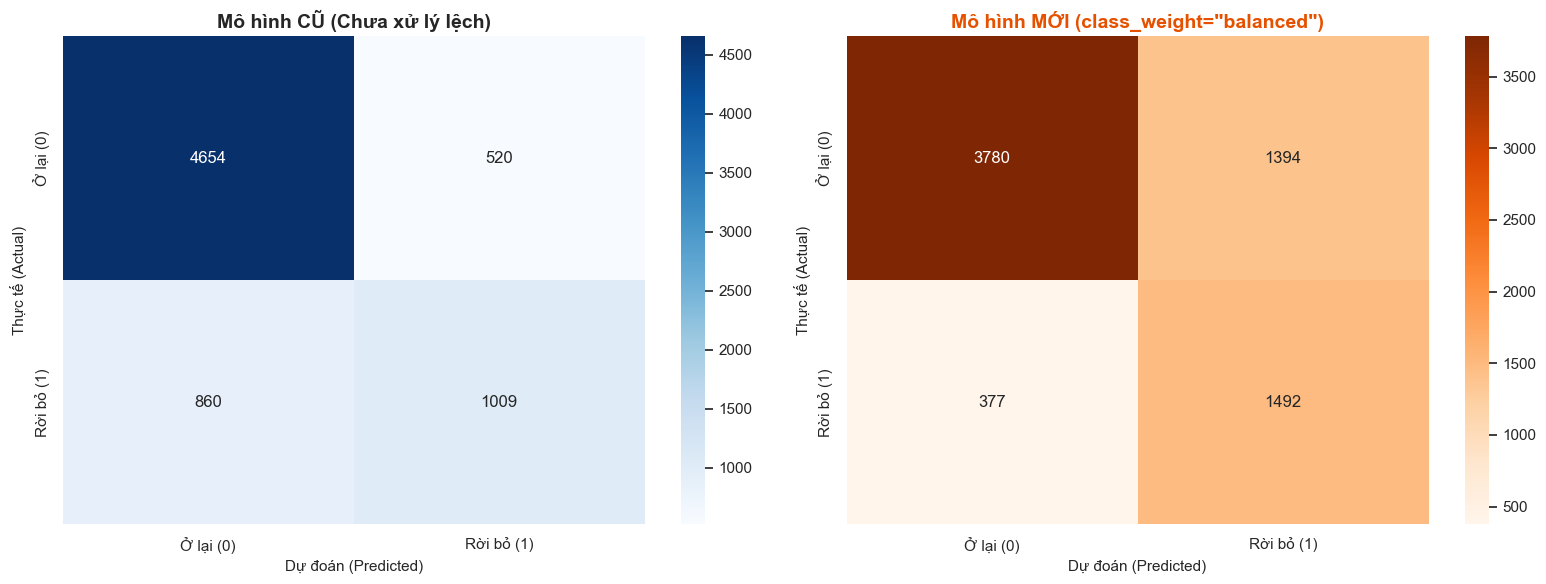


SO SÁNH BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)

[1] MÔ HÌNH CŨ:
              precision    recall  f1-score   support

   Ở lại (0)       0.84      0.90      0.87      5174
  Rời bỏ (1)       0.66      0.54      0.59      1869

    accuracy                           0.80      7043
   macro avg       0.75      0.72      0.73      7043
weighted avg       0.80      0.80      0.80      7043

--------------------------------------------------------------------------------

[2] MÔ HÌNH MỚI (class_weight='balanced'):
              precision    recall  f1-score   support

   Ở lại (0)       0.91      0.73      0.81      5174
  Rời bỏ (1)       0.52      0.80      0.63      1869

    accuracy                           0.75      7043
   macro avg       0.71      0.76      0.72      7043
weighted avg       0.81      0.75      0.76      7043



In [32]:

print("=" * 80)
print("ĐANG SO SÁNH 2 PHIÊN BẢN MÔ HÌNH (TRƯỚC VÀ SAU KHI CÂN BẰNG)...")
print("=" * 80)

# =====================================================================
# 1. HUẤN LUYỆN MÔ HÌNH MỚI (Có trọng số)
# =====================================================================
# Lưu ý: Biến final_model (mô hình cũ) và X_scaled, y vẫn đang được lưu trong bộ nhớ
final_model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
final_model_balanced.fit(X_scaled, y)

# =====================================================================
# 2. DỰ ĐOÁN TRÊN CẢ 2 MÔ HÌNH ĐỂ LẤY SỐ LIỆU SO SÁNH
# =====================================================================
y_pred_old = final_model.predict(X_scaled)          # Kết quả từ mô hình CŨ
y_pred_new = final_model_balanced.predict(X_scaled) # Kết quả từ mô hình MỚI

# Tính 2 ma trận nhầm lẫn
cm_old = confusion_matrix(y, y_pred_old)
cm_new = confusion_matrix(y, y_pred_new)

# =====================================================================
# 3. VẼ BIỂU ĐỒ SO SÁNH TRỰC QUAN (SIDE-BY-SIDE)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Biểu đồ 1: Mô hình CŨ (Màu Xanh) ---
sns.heatmap(cm_old, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
axes[0].set_title('Mô hình CŨ (Chưa xử lý lệch)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dự đoán (Predicted)', fontsize=11)
axes[0].set_ylabel('Thực tế (Actual)', fontsize=11)

# --- Biểu đồ 2: Mô hình MỚI (Màu Cam) ---
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
axes[1].set_title('Mô hình MỚI (class_weight="balanced")', fontsize=14, fontweight='bold', color='#E65100')
axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=11)
axes[1].set_ylabel('Thực tế (Actual)', fontsize=11)

plt.tight_layout()
plt.show()

# =====================================================================
# 4. IN BÁO CÁO PHÂN LOẠI CHI TIẾT
# =====================================================================
print("\n" + "=" * 80)
print("SO SÁNH BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("=" * 80)
print("\n[1] MÔ HÌNH CŨ:")
print(classification_report(y, y_pred_old, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

print("-" * 80)
print("\n[2] MÔ HÌNH MỚI (class_weight='balanced'):")
print(classification_report(y, y_pred_new, target_names=['Ở lại (0)', 'Rời bỏ (1)']))

# Test mô hình cái 

In [33]:

# =========================================================
# DỰ ĐOÁN CHO KHÁCH HÀNG MỚI (TELCO)
# ==========================================================

# 1. Tạo hồ sơ Khách hàng mới (Nhập đủ 15 cột X gốc)
# Giả lập một khách hàng có rủi ro cao: dùng cáp quang, hợp đồng từng tháng, trả tiền bằng check điện tử
new_customer = pd.DataFrame({
    'SeniorCitizen': [0],
    'Partner': ['No'],
    'Dependents': ['No'],
    'tenure': [4], # Mới dùng được 4 tháng
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [95.5]
})

# 2. One-hot encoding giống hệt tập Train
categorical_cols = [
    'Partner', 'Dependents', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

new_customer_encoded = pd.get_dummies(
    new_customer,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

# 3. Ép khung dữ liệu: Đảm bảo có đủ tất cả các cột dummy giống hệt tập X lúc huấn luyện
# Bất kỳ cột nào tập Train có mà khách hàng mới không sinh ra được, tự động điền số 0
new_customer_encoded = new_customer_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

# 4. Chuẩn hóa bằng scaler của toàn bộ dữ liệu (scaler_final)
# Lưu ý: Chỉ transform(), tuyệt đối không fit() lại
new_customer_scaled = pd.DataFrame(
    scaler_final.transform(new_customer_encoded),
    columns=X.columns
)

# 5. Dự đoán bằng MÔ HÌNH MỚI (đã cân bằng trọng số class_weight)
pred_class = final_model_balanced.predict(new_customer_scaled)[0]
pred_prob  = final_model_balanced.predict_proba(new_customer_scaled)[0][1]

# ==========================================================
# IN KẾT QUẢ
# ==========================================================
print("\n" + "=" * 50)
print("KẾT QUẢ DỰ ĐOÁN KHÁCH HÀNG MỚI (TELCO)")
print("=" * 50)
print(f"⭐ Xác suất rời bỏ   : {pred_prob * 100:.2f}%")
print(f"⭐ Dự đoán phân loại : {'🚨 RỜI BỎ (Churn=1)' if pred_class == 1 else '✅ Ở LẠI (Churn=0)'}")
print("=" * 50)


KẾT QUẢ DỰ ĐOÁN KHÁCH HÀNG MỚI (TELCO)
⭐ Xác suất rời bỏ   : 57.62%
⭐ Dự đoán phân loại : 🚨 RỜI BỎ (Churn=1)


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
